In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Cargo bases
df_2004 = pd.read_stata('usu_individual_t104.dta')
columnas = ["CH06", "CH12", "CH13", "CH14", "P21", "PP3E_TOT", "PP3F_TOT", "ESTADO", "CH04", "P47T", "AGLOMERADO"]
df_2024 = pd.read_excel('usu_individual_T124.xlsx', usecols=columnas)

# Estandarizo nombres de columnas
df_2004.columns = df_2004.columns.str.upper()
df_2024.columns = df_2024.columns.str.upper()

# Agrego columna de AÑO
df_2004['AÑO'] = 2004
df_2024['AÑO'] = 2024



In [4]:
# Edad
df_2004['EDAD'] = pd.to_numeric(df_2004['CH06'], errors='coerce')
df_2024['EDAD'] = pd.to_numeric(df_2024['CH06'], errors='coerce')

# Edad al cuadrado
df_2004['EDAD2'] = df_2004['EDAD'] ** 2
df_2024['EDAD2'] = df_2024['EDAD'] ** 2

# Convierto CH12, CH13, CH14 a numérico
df_2004['CH12'] = pd.to_numeric(df_2004['CH12'], errors='coerce')
df_2004['CH13'] = pd.to_numeric(df_2004['CH13'], errors='coerce')
df_2004['CH14'] = pd.to_numeric(df_2004['CH14'], errors='coerce')

df_2024['CH12'] = pd.to_numeric(df_2024['CH12'], errors='coerce')
df_2024['CH13'] = pd.to_numeric(df_2024['CH13'], errors='coerce')
df_2024['CH14'] = pd.to_numeric(df_2024['CH14'], errors='coerce')

# Construcción correcta de EDUC
df_2004['EDUC'] = df_2004['CH12'].fillna(0) + df_2004['CH13'].fillna(0) + df_2004['CH14'].fillna(0)
df_2024['EDUC'] = df_2024['CH12'].fillna(0) + df_2024['CH13'].fillna(0) + df_2024['CH14'].fillna(0)

# Dummy MUJER
df_2004['MUJER'] = (df_2004['CH04'] == 2).astype(int)
df_2024['MUJER'] = (df_2024['CH04'] == 2).astype(int)

# Horas trabajadas (capadas entre 0 y 168)
df_2004['HORASTRAB'] = df_2004['P21'].clip(lower=0, upper=168)
df_2024['HORASTRAB'] = df_2024['P21'].clip(lower=0, upper=168)

# Salario semanal
df_2004['SALARIO_SEMANAL'] = df_2004['PP3E_TOT'].fillna(0) + df_2004['PP3F_TOT'].fillna(0)
df_2024['SALARIO_SEMANAL'] = df_2024['PP3E_TOT'].fillna(0) + df_2024['PP3F_TOT'].fillna(0)


In [5]:
# Para 2004: mapeo de string a número
map_estado_2004 = {
    'Ocupado': 1,
    'Desocupado': 2,
    'Inactivo': 3,
    'Menor de 10 años': 4,
    'Entrevista individual no realizada (no respuesta al cuestionario individual)': 0
}

df_2004['ESTADO_NUM'] = df_2004['ESTADO'].map(map_estado_2004)

# Para 2024: ya es número
df_2024['ESTADO_NUM'] = df_2024['ESTADO']



In [14]:
  # Filtro CABA
df_caba_2004 = df_2004[df_2004['AGLOMERADO'] == 'Ciudad de Buenos Aires']
df_caba_2024 = df_2024[df_2024['AGLOMERADO'] == 32]

# Uno las bases
df_caba = pd.concat([df_caba_2004, df_caba_2024], ignore_index=True)
# Creo la variable EDUC_SECUNDARIO_COMPLETO
df_caba['EDUC_SECUNDARIO_COMPLETO'] = (df_caba['EDUC'] >= 12).astype(int)


# armp respondieron
respondieron = df_caba[df_caba['ESTADO_NUM'].isin([1, 2])].copy()

# Actualizo respondieron_2004 y respondieron_2024
respondieron_2004 = respondieron[respondieron['AÑO'] == 2004].copy()
respondieron_2024 = respondieron[respondieron['AÑO'] == 2024].copy()

# Control
print('NaN en respondieron["EDUC"]:', respondieron['EDUC'].isna().sum())
print('NaN en respondieron["EDUC_SECUNDARIO_COMPLETO"]:', respondieron['EDUC_SECUNDARIO_COMPLETO'].isna().sum())


NaN en respondieron["EDUC"]: 0
NaN en respondieron["EDUC_SECUNDARIO_COMPLETO"]: 0


In [7]:
#PARTE A
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Defino las variables a usar
variables_X = ['EDAD', 'EDAD2', 'EDUC', 'MUJER', 'HORASTRAB', 'SALARIO_SEMANAL']

# --------------------------
# Parte A - Año 2004
# --------------------------

# Filtro respondieron para 2004
respondieron_2004 = respondieron[respondieron['AÑO'] == 2004].copy()

# Defino X e y
X_2004 = respondieron_2004[variables_X]
y_2004 = (respondieron_2004['ESTADO_NUM'] == 2).astype(int)

# Split
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = train_test_split(
    X_2004, y_2004, test_size=0.3, random_state=444
)

# Imputo EDUC después del split
mediana_educ_2004 = X_train_2004['EDUC'].median()
X_train_2004['EDUC'] = X_train_2004['EDUC'].fillna(mediana_educ_2004).astype(float)
X_test_2004['EDUC'] = X_test_2004['EDUC'].fillna(mediana_educ_2004).astype(float)

# Agrego columna de unos (como pide el enunciado)
X_train_2004_const = sm.add_constant(X_train_2004)
X_test_2004_const = sm.add_constant(X_test_2004)

# --------------------------
# Parte A - Año 2024
# --------------------------

# Filtro respondieron para 2024
respondieron_2024 = respondieron[respondieron['AÑO'] == 2024].copy()

# Defino X e y
X_2024 = respondieron_2024[variables_X]
y_2024 = (respondieron_2024['ESTADO_NUM'] == 2).astype(int)

# Split
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = train_test_split(
    X_2024, y_2024, test_size=0.3, random_state=444
)

# Imputo EDUC después del split
mediana_educ_2024 = X_train_2024['EDUC'].median()
X_train_2024['EDUC'] = X_train_2024['EDUC'].fillna(mediana_educ_2024).astype(float)
X_test_2024['EDUC'] = X_test_2024['EDUC'].fillna(mediana_educ_2024).astype(float)

# Agrego columna de unos
X_train_2024_const = sm.add_constant(X_train_2024)
X_test_2024_const = sm.add_constant(X_test_2024)

# --------------------------
# Control: veo que no queden NaN
# --------------------------

print('\nNaN en X_train_2004:')
print(X_train_2004_const.isna().sum())

print('\nNaN en X_test_2004:')
print(X_test_2004_const.isna().sum())

print('\nNaN en X_train_2024:')
print(X_train_2024_const.isna().sum())

print('\nNaN en X_test_2024:')
print(X_test_2024_const.isna().sum())
# --------------------------
# Tabla de diferencias de medias (como pide el enunciado, sin const)
# --------------------------

tabla_diff_2004 = X_train_2004_const.drop(columns='const').mean() - X_test_2004_const.drop(columns='const').mean()
print('\nDiferencia de medias - Año 2004')
print(tabla_diff_2004)

tabla_diff_2024 = X_train_2024_const.drop(columns='const').mean() - X_test_2024_const.drop(columns='const').mean()
print('\nDiferencia de medias - Año 2024')
print(tabla_diff_2024)



NaN en X_train_2004:
const              0
EDAD               0
EDAD2              0
EDUC               0
MUJER              0
HORASTRAB          0
SALARIO_SEMANAL    0
dtype: int64

NaN en X_test_2004:
const              0
EDAD               0
EDAD2              0
EDUC               0
MUJER              0
HORASTRAB          0
SALARIO_SEMANAL    0
dtype: int64

NaN en X_train_2024:
const              0
EDAD               0
EDAD2              0
EDUC               0
MUJER              0
HORASTRAB          0
SALARIO_SEMANAL    0
dtype: int64

NaN en X_test_2024:
const              0
EDAD               0
EDAD2              0
EDUC               0
MUJER              0
HORASTRAB          0
SALARIO_SEMANAL    0
dtype: int64

Diferencia de medias - Año 2004
EDAD                 1.872446
EDAD2              191.537463
EDUC                 0.616779
MUJER                0.000000
HORASTRAB           -1.335217
SALARIO_SEMANAL     -4.918333
dtype: float64

Diferencia de medias - Año 2024
EDAD         

In [15]:
#PARTE B 2
import statsmodels.api as sm

# Defino función para armar los modelos
def armar_modelos_lineales(X_train, respondieron_base, año):

    # Filtro ocupados con ingreso y horas válidas
    ocupados_train_idx = respondieron_base.loc[X_train.index]
    ocupados_train_idx = ocupados_train_idx[
        (ocupados_train_idx['ESTADO_NUM'] == 1) &
        (ocupados_train_idx['SALARIO_SEMANAL'].notna()) &
        (ocupados_train_idx['SALARIO_SEMANAL'] > 0) &
        (ocupados_train_idx['HORASTRAB'].notna()) &
        (ocupados_train_idx['HORASTRAB'] > 0)
    ]

    # Defino X e y para regresión
    X_ocupados = ocupados_train_idx[variables_X + ['EDUC_SECUNDARIO_COMPLETO']].copy()
    y_ocupados = ocupados_train_idx['SALARIO_SEMANAL'].copy()

    # Imputo NaN en EDUC
    mediana_educ = X_ocupados['EDUC'].median()
    X_ocupados['EDUC'] = X_ocupados['EDUC'].fillna(mediana_educ).astype(float)

    # Combino X e y
    df_model = X_ocupados.copy()
    df_model['SALARIO_SEMANAL'] = y_ocupados

    # Elimino filas con NaN
    df_model = df_model.dropna()

    # Redefino X e y
    X_ocupados = df_model[variables_X + ['EDUC_SECUNDARIO_COMPLETO']]
    y_ocupados = df_model['SALARIO_SEMANAL']

    # Imprimo control
    print(f'\nAño {año} - Cantidad de ocupados usados en el modelo: {len(X_ocupados)}')

    # Armo los modelos

    # Modelo 1
    X1 = sm.add_constant(X_ocupados[['EDAD']])
    modelo1 = sm.OLS(y_ocupados, X1).fit()

    # Modelo 2
    X2 = sm.add_constant(X_ocupados[['EDAD', 'EDAD2']])
    modelo2 = sm.OLS(y_ocupados, X2).fit()

    # Modelo 3
    X3 = sm.add_constant(X_ocupados[['EDAD', 'EDAD2', 'EDUC']])
    modelo3 = sm.OLS(y_ocupados, X3).fit()

    # Modelo 4
    X4 = sm.add_constant(X_ocupados[['EDAD', 'EDAD2', 'EDUC', 'MUJER']])
    modelo4 = sm.OLS(y_ocupados, X4).fit()

    # Modelo 5 (con HORASTRAB y EDUC_SECUNDARIO_COMPLETO)
    X5 = sm.add_constant(X_ocupados[['EDAD', 'EDAD2', 'EDUC', 'MUJER', 'HORASTRAB', 'EDUC_SECUNDARIO_COMPLETO']])
    modelo5 = sm.OLS(y_ocupados, X5).fit()

    # Imprimo resultados
    print(f'\nModelo 1 - Año {año}')
    print(modelo1.summary())

    print(f'\nModelo 2 - Año {año}')
    print(modelo2.summary())

    print(f'\nModelo 3 - Año {año}')
    print(modelo3.summary())

    print(f'\nModelo 4 - Año {año}')
    print(modelo4.summary())

    print(f'\nModelo 5 - Año {año}')
    print(modelo5.summary())

    # Devuelvo los modelos
    return modelo1, modelo2, modelo3, modelo4, modelo5

# Parte B2 - Año 2004
modelos_2004 = armar_modelos_lineales(X_train_2004, respondieron_2004, 2004)

# Parte B2 - Año 2024
modelos_2024 = armar_modelos_lineales(X_train_2024, respondieron_2024, 2024)



Año 2004 - Cantidad de ocupados usados en el modelo: 503

Modelo 1 - Año 2004
                            OLS Regression Results                            
Dep. Variable:        SALARIO_SEMANAL   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2879
Date:                Tue, 03 Jun 2025   Prob (F-statistic):              0.592
Time:                        04:47:20   Log-Likelihood:                -3016.4
No. Observations:                 503   AIC:                             6037.
Df Residuals:                     501   BIC:                             6045.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [19]:
#PARTE B 3
def armar_tabla_metricas_robusto(modelos, df_test, año):
    resultados = {'Modelo': [], 'MSE': [], 'RMSE': [], 'MAE': []}

    y_test = df_test['SALARIO_SEMANAL']

    for i, modelo in enumerate(modelos):
        # Acá saco directamente las variables que el modelo espera
        vars_modelo = modelo.model.exog_names
        X_test_i = df_test[vars_modelo]

        y_pred = modelo.predict(X_test_i)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)

        resultados['Modelo'].append(f'Modelo {i+1}')
        resultados['MSE'].append(round(mse, 2))
        resultados['RMSE'].append(round(rmse, 2))
        resultados['MAE'].append(round(mae, 2))

    df_resultados = pd.DataFrame(resultados)
    print(f'\nTabla de métricas - Año {año}:')
    print(df_resultados.to_string(index=False))

    return df_resultados

# Armo las tablas
tabla_metricas_2004 = armar_tabla_metricas_robusto(modelos_2004, df_test_2004, 2004)
tabla_metricas_2024 = armar_tabla_metricas_robusto(modelos_2024, df_test_2024, 2024)




Tabla de métricas - Año 2004:
  Modelo      MSE   RMSE   MAE
Modelo 1 13182.63 114.82 29.56
Modelo 2 13161.72 114.72 29.48
Modelo 3 13160.31 114.72 29.66
Modelo 4 13160.31 114.72 29.66
Modelo 5 13104.44 114.47 29.33

Tabla de métricas - Año 2024:
  Modelo    MSE  RMSE   MAE
Modelo 1 291.99 17.09 13.03
Modelo 2 282.30 16.80 13.01
Modelo 3 279.98 16.73 12.95
Modelo 4 276.98 16.64 12.80
Modelo 5 269.64 16.42 12.58


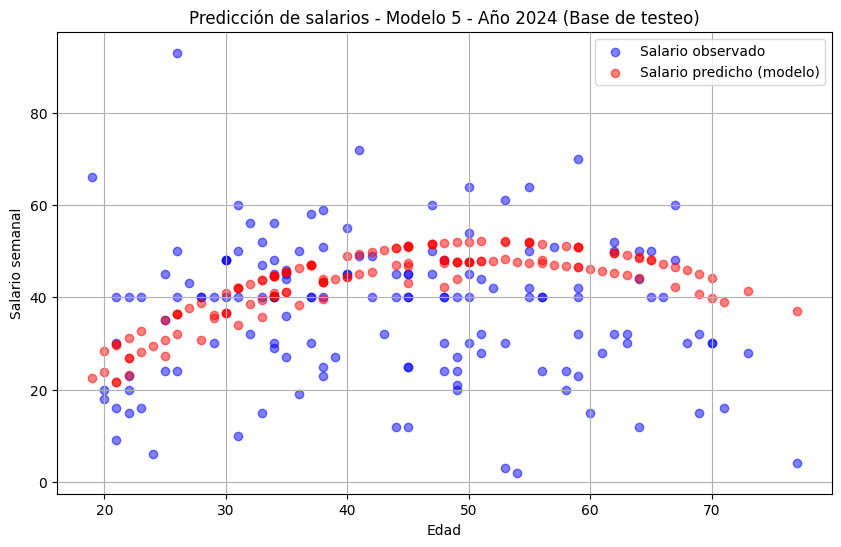

In [20]:
#PARTE B 4
import matplotlib.pyplot as plt

# Selecciono el modelo de mejor performance → Modelo 5 de 2024
modelo_mejor = modelos_2024[4]

# Base de test: 2024
df_plot = df_test_2024.copy()

# Variables que usó Modelo 5
vars_modelo_5 = modelo_mejor.model.exog_names
X_test_plot = df_plot[vars_modelo_5]

# Predicción
df_plot['SALARIO_SEMANAL_HAT'] = modelo_mejor.predict(X_test_plot)

# Gráfico
plt.figure(figsize=(10, 6))

# Puntos observados
plt.scatter(df_plot['EDAD'], df_plot['SALARIO_SEMANAL'], color='blue', alpha=0.5, label='Salario observado')

# Puntos predichos
plt.scatter(df_plot['EDAD'], df_plot['SALARIO_SEMANAL_HAT'], color='red', alpha=0.5, label='Salario predicho (modelo)')

plt.xlabel('Edad')
plt.ylabel('Salario semanal')
plt.title('Predicción de salarios - Modelo 5 - Año 2024 (Base de testeo)')
plt.legend()
plt.grid(True)
plt.show()


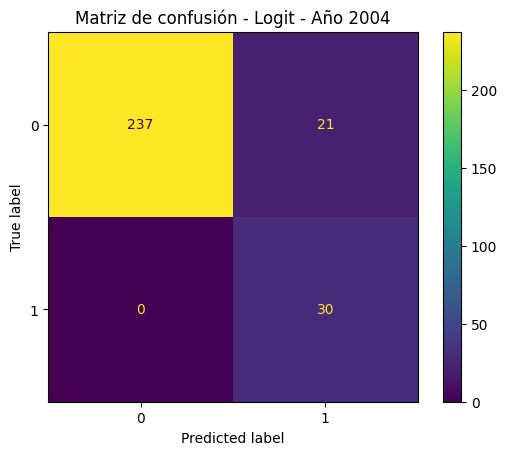

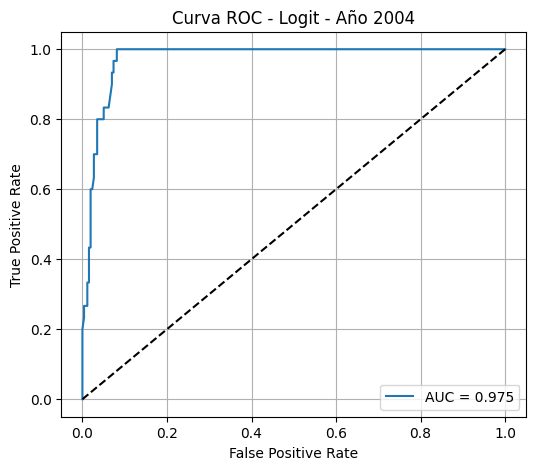

Logit - Año 2004 - Accuracy test: 0.927 - AUC: 0.975


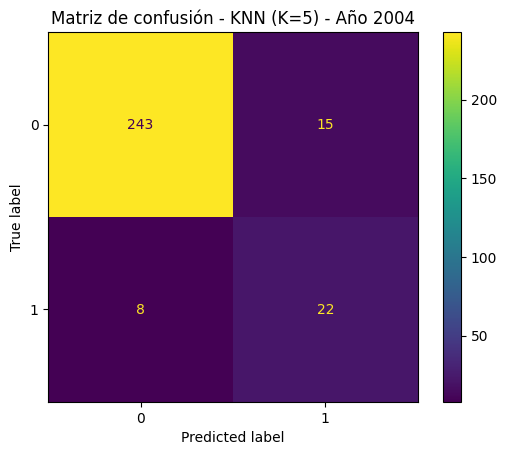

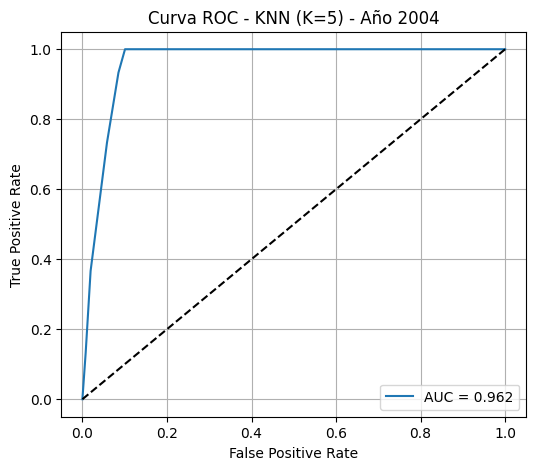

KNN (K=5) - Año 2004 - Accuracy test: 0.920 - AUC: 0.962


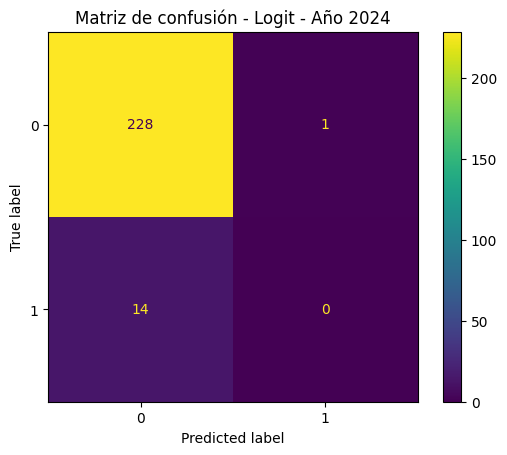

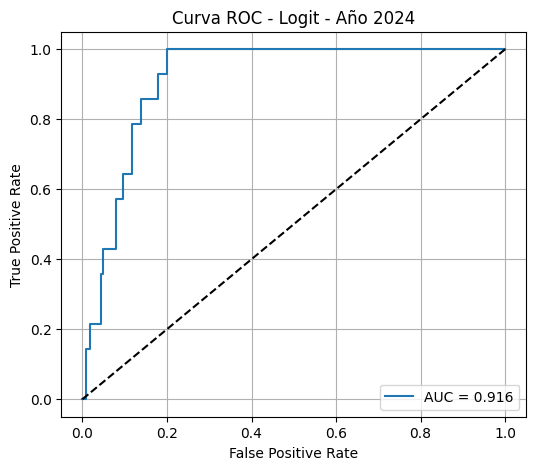

Logit - Año 2024 - Accuracy test: 0.938 - AUC: 0.916


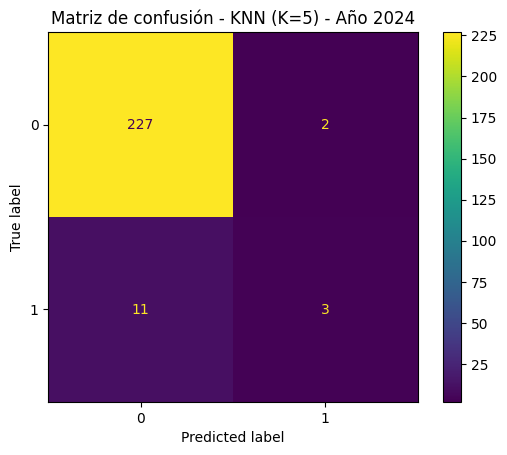

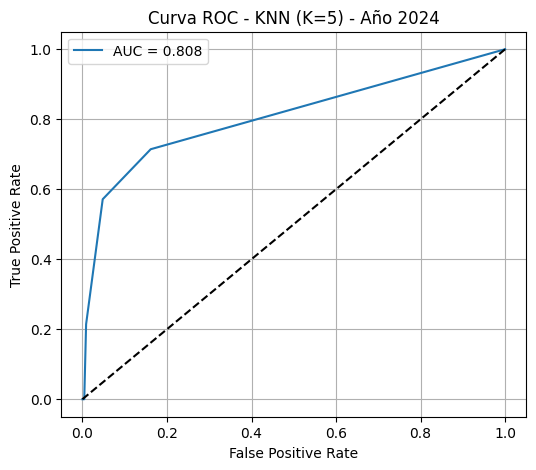

KNN (K=5) - Año 2024 - Accuracy test: 0.947 - AUC: 0.808


In [23]:
#PARTE C 5
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Variables a usar
variables_X_logit = ['EDAD', 'EDAD2', 'EDUC', 'MUJER', 'HORASTRAB', 'EDUC_SECUNDARIO_COMPLETO']

# 2004 - Armo X e y
X_logit_2004 = respondieron_2004[variables_X_logit].copy()
y_logit_2004 = (respondieron_2004['ESTADO_NUM'] == 2).astype(int)

# Split 2004
X_train_logit_2004, X_test_logit_2004, y_train_logit_2004, y_test_logit_2004 = train_test_split(
    X_logit_2004, y_logit_2004, test_size=0.3, random_state=444
)

# 2024 - Armo X e y
X_logit_2024 = respondieron_2024[variables_X_logit].copy()
y_logit_2024 = (respondieron_2024['ESTADO_NUM'] == 2).astype(int)

# Split 2024
X_train_logit_2024, X_test_logit_2024, y_train_logit_2024, y_test_logit_2024 = train_test_split(
    X_logit_2024, y_logit_2024, test_size=0.3, random_state=444
)

# Función para evaluar y graficar
def evaluar_modelo_clasificacion(modelo, X_test, y_test, nombre_modelo, año):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Matriz de confusión - {nombre_modelo} - Año {año}')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {nombre_modelo} - Año {año}')
    plt.legend()
    plt.grid(True)
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    print(f'{nombre_modelo} - Año {año} - Accuracy test: {accuracy:.3f} - AUC: {auc:.3f}')

# LOGIT - 2004
logit_model_2004 = LogisticRegression(max_iter=1000)
logit_model_2004.fit(X_train_logit_2004, y_train_logit_2004)

evaluar_modelo_clasificacion(logit_model_2004, X_test_logit_2004, y_test_logit_2004, 'Logit', 2004)

# KNN (K=5) - 2004
knn_model_2004 = KNeighborsClassifier(n_neighbors=5)
knn_model_2004.fit(X_train_logit_2004, y_train_logit_2004)

evaluar_modelo_clasificacion(knn_model_2004, X_test_logit_2004, y_test_logit_2004, 'KNN (K=5)', 2004)

# LOGIT - 2024
logit_model_2024 = LogisticRegression(max_iter=1000)
logit_model_2024.fit(X_train_logit_2024, y_train_logit_2024)

evaluar_modelo_clasificacion(logit_model_2024, X_test_logit_2024, y_test_logit_2024, 'Logit', 2024)

# KNN (K=5) - 2024
knn_model_2024 = KNeighborsClassifier(n_neighbors=5)
knn_model_2024.fit(X_train_logit_2024, y_train_logit_2024)

evaluar_modelo_clasificacion(knn_model_2024, X_test_logit_2024, y_test_logit_2024, 'KNN (K=5)', 2024)



In [25]:
#PARTE C 6
respondieron = df_caba[df_caba['ESTADO_NUM'].isin([1, 2])].copy()
norespondieron = df_caba[~df_caba['ESTADO_NUM'].isin([1, 2])].copy()

# Control
print(f'Base norespondieron: {norespondieron.shape[0]} registros')

# Variables que usó el Logit
variables_X_logit = ['EDAD', 'EDAD2', 'EDUC', 'MUJER', 'HORASTRAB', 'EDUC_SECUNDARIO_COMPLETO']

# Armo X para la base norespondieron
X_norespondieron_2024 = norespondieron[norespondieron['AÑO'] == 2024][variables_X_logit].copy()

# Predigo probabilidades
y_prob_norespondieron = logit_model_2024.predict_proba(X_norespondieron_2024)[:, 1]

# Clasifico con p > 0.5
y_pred_norespondieron = (y_prob_norespondieron > 0.5).astype(int)

# Calculo proporción de desocupados
proporcion_desocupados = y_pred_norespondieron.mean()

# Imprimo resultado
print(f'Proporción de personas no respondieron clasificadas como desocupadas (2024): {proporcion_desocupados:.3f}')


Base norespondieron: 1493 registros
Proporción de personas no respondieron clasificadas como desocupadas (2024): 0.352


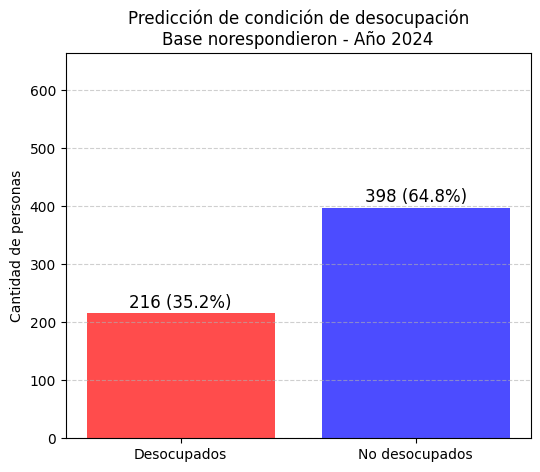

In [26]:
#Grafiquito porque me gustan
import matplotlib.pyplot as plt

# Calculo cantidad de desocupados y no desocupados
n_total = len(y_pred_norespondieron)
n_desocupados = y_pred_norespondieron.sum()
n_no_desocupados = n_total - n_desocupados

# Datos para el gráfico
labels = ['Desocupados', 'No desocupados']
values = [n_desocupados, n_no_desocupados]

# Gráfico
plt.figure(figsize=(6, 5))
plt.bar(labels, values, color=['red', 'blue'], alpha=0.7)

# Título y etiquetas
plt.title('Predicción de condición de desocupación\nBase norespondieron - Año 2024')
plt.ylabel('Cantidad de personas')
plt.ylim(0, n_total + 50)

# Muestro el porcentaje en cada barra
for i, v in enumerate(values):
    plt.text(i, v + 10, f'{v} ({v / n_total:.1%})', ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
